# ROPE exercise notebook  


## 1. Background

In this exercise, the daily HBV rainfall–runoff model for the Kirchentellinsfurt sub-catchment (station 420) is used. The analysis is done for two decades, 1971–1980 and 1981–1990, which are used for calibration and validation. Since the calibration is done over a broad parameter space, so we do not have just a single optimum. Different parameter vectors can generate acceptable simulations of the discharge.  

This is the reason for using the Robust Parameter Estimation (ROPE). The ROPE starts from a threshold accepted ensemble and selects a smaller subset of parameter verctors that are acceptable but also geometrically dissimilar from one another, so that these vectors are more robust. If we consider the whole accepted cloud, the ensemble is large and redundant, but if we consider only the single best parameter vector, we lose the uncertainty information.
So, starting from a chosen threshold, and then reducing that accepted cloud to a smaller subset and then assesing if the reduced subset still gets the acceptable discharge envelop range.

The problem of equifinality in hydrological modeling is the main basis of considering ROPE. Different parameter vectors can produce similarly good model performance, but their actual parameter values are different from each other. So, good model performance does not necessarily correspond to one unique optimum. The goal is to keep a smaller but still representative set of plausible parameter sets, so that the uncertainty is preserved. 



## 2. Methodological idea

The objective function used in the exercise is

\\[
\\text{objective} = 1 - NS
\\]

where \(NS\) is the Nash–Sutcliffe efficiency.  
Since the objective is minimized, **smaller values correspond to better model performance**.

The procedure can be summarised as follows:

1. generate many parameter vectors during calibration,  
2. retain only those vectors that satisfy the chosen objective threshold,  
3. apply ROPE to reduce the accepted cloud,  
4. build discharge envelopes from both the thresholded ensemble and the ROPE subset,  
5. compare their coverage of the observed discharge,  
6. validate the retained subset on the opposite decade.

The envelope plots classify the observations into three groups:

- **Lo**: observations below the lower envelope  
- **OK**: observations inside the envelope  
- **Hi**: observations above the upper envelope  

From these counts, the outside fraction is computed as

\\[
\\frac{Lo + Hi}{Lo + OK + Hi}
\\]


A threshold is regarded as acceptable only if the ROPE-based discharge envelope keeps the fraction of observations outside the envelope at about 1 percent or below. The final threshold is the lowest tested threshold for which the ROPE subset still provides satisfactory envelope coverage.


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd

ROOT = Path("/Users/nafisaraihana/Downloads/UQ_Hydrology_MOOC_Seminar/Block3/rope_exercise_pycodes/mmuq_rope__exercise3")

# Calibration folders
CAL_71 = ROOT / "hbv_daily_1971_1980_cb"
CAL_81 = ROOT / "hbv_daily_1981_1990_cb"

# Validation folders
VAL_71_TO_81 = CAL_71 / "hbv_daily_1981_1990_vd"
VAL_81_TO_71 = CAL_81 / "hbv_daily_1971_1980_vd"

print("CAL_71      =", CAL_71)
print("CAL_81      =", CAL_81)
print("VAL_71_TO_81=", VAL_71_TO_81)
print("VAL_81_TO_71=", VAL_81_TO_71)

def show_image(folder, filename, figsize=(12, 7), title=None):
    path = folder / filename
    if not path.exists():
        print("Missing:", path)
        return
    img = mpimg.imread(path)
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis("off")
    plt.title(title if title else filename)
    plt.show()

def show_grid(folder, filenames, ncols=2, figsize=(14, 10)):
    existing = [fn for fn in filenames if (folder / fn).exists()]
    if not existing:
        print("No matching images found in", folder)
        return

    n = len(existing)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for ax, fn in zip(axes, existing):
        img = mpimg.imread(folder / fn)
        ax.imshow(img)
        ax.set_title(fn, fontsize=9)
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

CAL_71      = /Users/nafisaraihana/Downloads/UQ_Hydrology_MOOC_Seminar/Block3/rope_exercise_pycodes/mmuq_rope__exercise3/hbv_daily_1971_1980_cb
CAL_81      = /Users/nafisaraihana/Downloads/UQ_Hydrology_MOOC_Seminar/Block3/rope_exercise_pycodes/mmuq_rope__exercise3/hbv_daily_1981_1990_cb
VAL_71_TO_81= /Users/nafisaraihana/Downloads/UQ_Hydrology_MOOC_Seminar/Block3/rope_exercise_pycodes/mmuq_rope__exercise3/hbv_daily_1971_1980_cb/hbv_daily_1981_1990_vd
VAL_81_TO_71= /Users/nafisaraihana/Downloads/UQ_Hydrology_MOOC_Seminar/Block3/rope_exercise_pycodes/mmuq_rope__exercise3/hbv_daily_1981_1990_cb/hbv_daily_1971_1980_vd


## 4. Overview tables

Before turning to the figures, the main calibration and validation counts are summarised in tables. This makes it easier to see the size reduction after ROPE and the corresponding outside fractions.

In [3]:
calibration_summary = pd.DataFrame(
    {
        "threshold_n": [44031, 38606],
        "threshold_Lo": [2, 0],
        "threshold_OK": [3284, 3281],
        "threshold_Hi": [2, 6],
        "rope_n": [239, 212],
        "rope_Lo": [9, 1],
        "rope_OK": [3265, 3273],
        "rope_Hi": [14, 13],
    },
    index=["1971-1980 calibration", "1981-1990 calibration"],
)

calibration_summary["threshold_outside_%"] = 100 * (
    (calibration_summary["threshold_Lo"] + calibration_summary["threshold_Hi"])
    / (calibration_summary["threshold_Lo"] + calibration_summary["threshold_OK"] + calibration_summary["threshold_Hi"])
)

calibration_summary["rope_outside_%"] = 100 * (
    (calibration_summary["rope_Lo"] + calibration_summary["rope_Hi"])
    / (calibration_summary["rope_Lo"] + calibration_summary["rope_OK"] + calibration_summary["rope_Hi"])
)

calibration_summary

,threshold_n,threshold_Lo,threshold_OK,threshold_Hi,rope_n,rope_Lo,rope_OK,rope_Hi,threshold_outside_%,rope_outside_%
1971-1980 calibration,44031,2,3284,2,239,9,3265,14,0.121655,0.699513
1981-1990 calibration,38606,0,3281,6,212,1,3273,13,0.182537,0.425920


In [2]:
validation_summary = pd.DataFrame(
    {
        "rope_n": [239, 212],
        "val_Lo": [11, 4],
        "val_OK": [3263, 3272],
        "val_Hi": [13, 12],
        "better_%": [88.7, 6.6],
        "worse_%": [11.3, 93.4],
    },
    index=[
        "1971-1980 subset validated on 1981-1990",
        "1981-1990 subset validated on 1971-1980",
    ],
)

validation_summary["val_outside_%"] = 100 * (
    (validation_summary["val_Lo"] + validation_summary["val_Hi"])
    / (validation_summary["val_Lo"] + validation_summary["val_OK"] + validation_summary["val_Hi"])
)

validation_summary

,rope_n,val_Lo,val_OK,val_Hi,better_%,worse_%,val_outside_%
1971-1980 subset validated on 1981-1990,239,11,3263,13,88.7,11.3,0.730149
1981-1990 subset validated on 1971-1980,212,4,3272,12,6.6,93.4,0.486618


---

# Part A. Calibration decade 1971–1980

## A1. Threshold envelope for 1971–1980

The first result for this decade is the envelope obtained from the full threshold-accepted ensemble.  
This figure shows the coverage before the accepted cloud is reduced by ROPE.


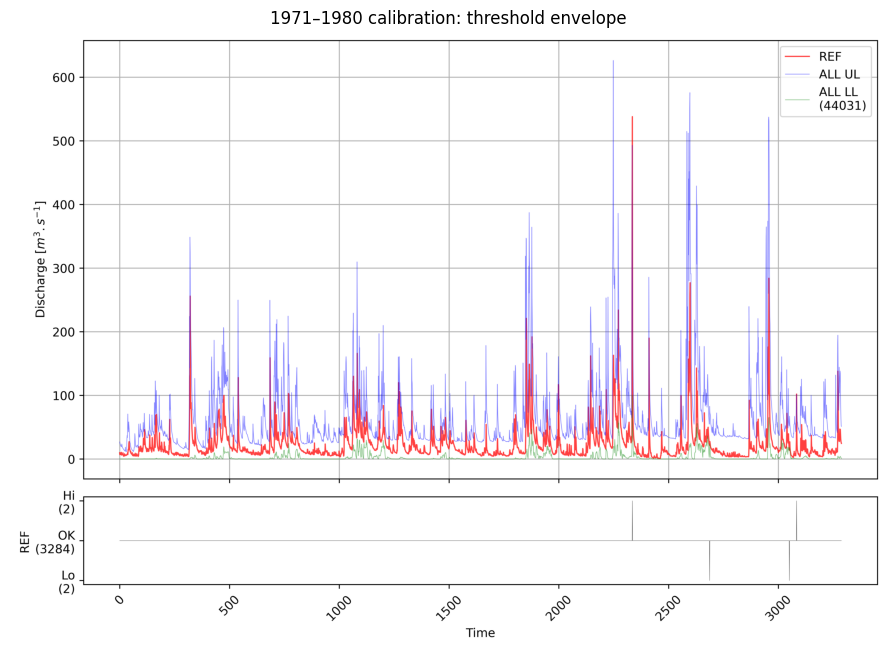

In [3]:
show_image(
    CAL_71,
    "420_envp_all.png",
    figsize=(14, 8),
    title="1971–1980 calibration: threshold envelope"
)

### Interpretation

- **REF** is the observed discharge.
- **ALL UL** is the upper envelope from the full thresholded ensemble.
- **ALL LL** is the lower envelope from the same ensemble.
- The number in brackets is the number of retained thresholded parameter vectors.

The lower panel counts how many observations are:

- **Lo** = below the envelope,
- **OK** = inside the envelope,
- **Hi** = above the envelope.

For this decade, the thresholded ensemble has:

- **Lo = 2**
- **OK = 3284**
- **Hi = 2**

So the outside fraction is about **0.12%**.  
This tells us that the thresholded cloud covers the observed discharge extremely well, but it is still a very large set.

## A2. ROPE envelope for 1971–1980

The next figure shows what happens after ROPE is applied to the threshold-accepted cloud.

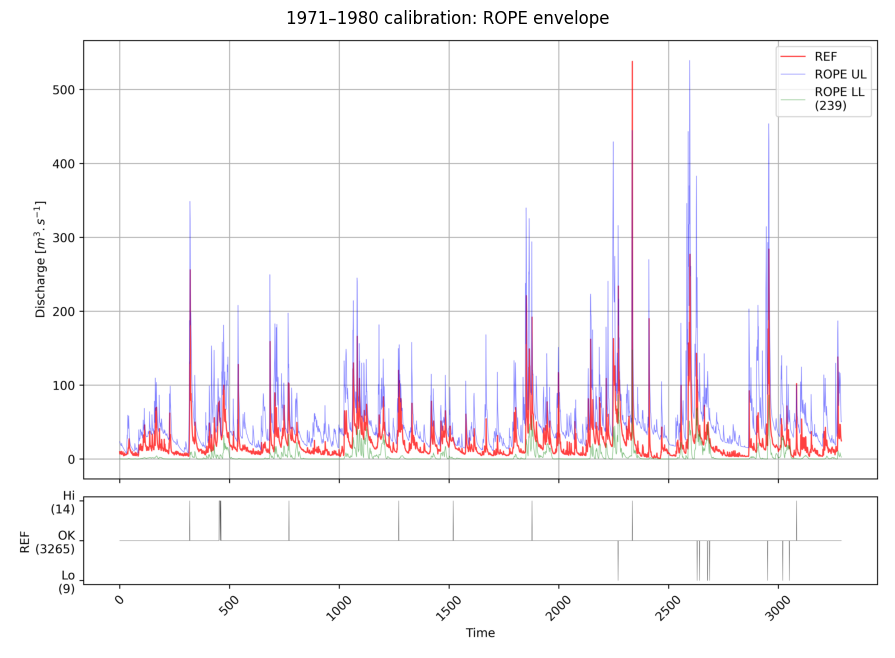

In [4]:
show_image(
    CAL_71,
    "420_envp_rope.png",
    figsize=(14, 8),
    title="1971–1980 calibration: ROPE envelope"
)

### Interpretation

After ROPE, the accepted cloud is reduced from **44,031** parameter vectors to **239**.

The ROPE envelope counts are:

- **Lo = 9**
- **OK = 3265**
- **Hi = 14**

So the outside fraction becomes about **0.70%**.


The ensemble becomes much smaller, but the coverage still remains acceptable and stays below the approximate 1% level.

So for this decade, ROPE removes a lot of redundancy without destroying the envelope.

## A3. Objective distribution before and after ROPE

The next plot compares the objective-value distribution of the thresholded ensemble with that of the ROPE subset.


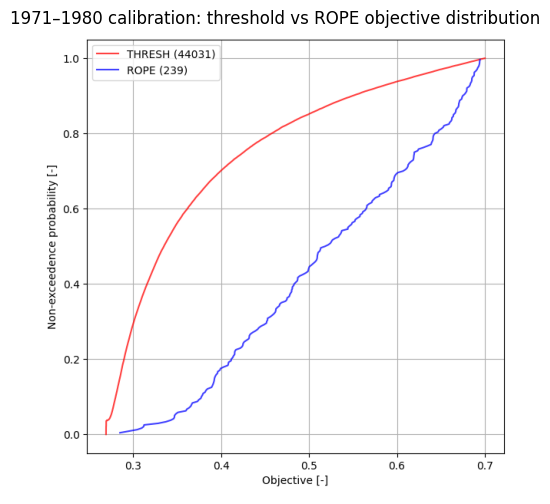

In [5]:
show_image(
    CAL_71,
    "420_objs_all_rope_dist.png",
    figsize=(8, 6),
    title="1971–1980 calibration: threshold vs ROPE objective distribution"
)

### What I take from this plot

The red curve is the full thresholded ensemble.  
The blue curve is the ROPE subset.

The ROPE curve is shifted slightly toward higher objective values.  
ROPE keeps a much smaller subset that is still acceptable and less redundant.



## A4. Parameter cloud before and after ROPE

The pairwise scatter plots below show the accepted parameter cloud before and after the ROPE reduction.


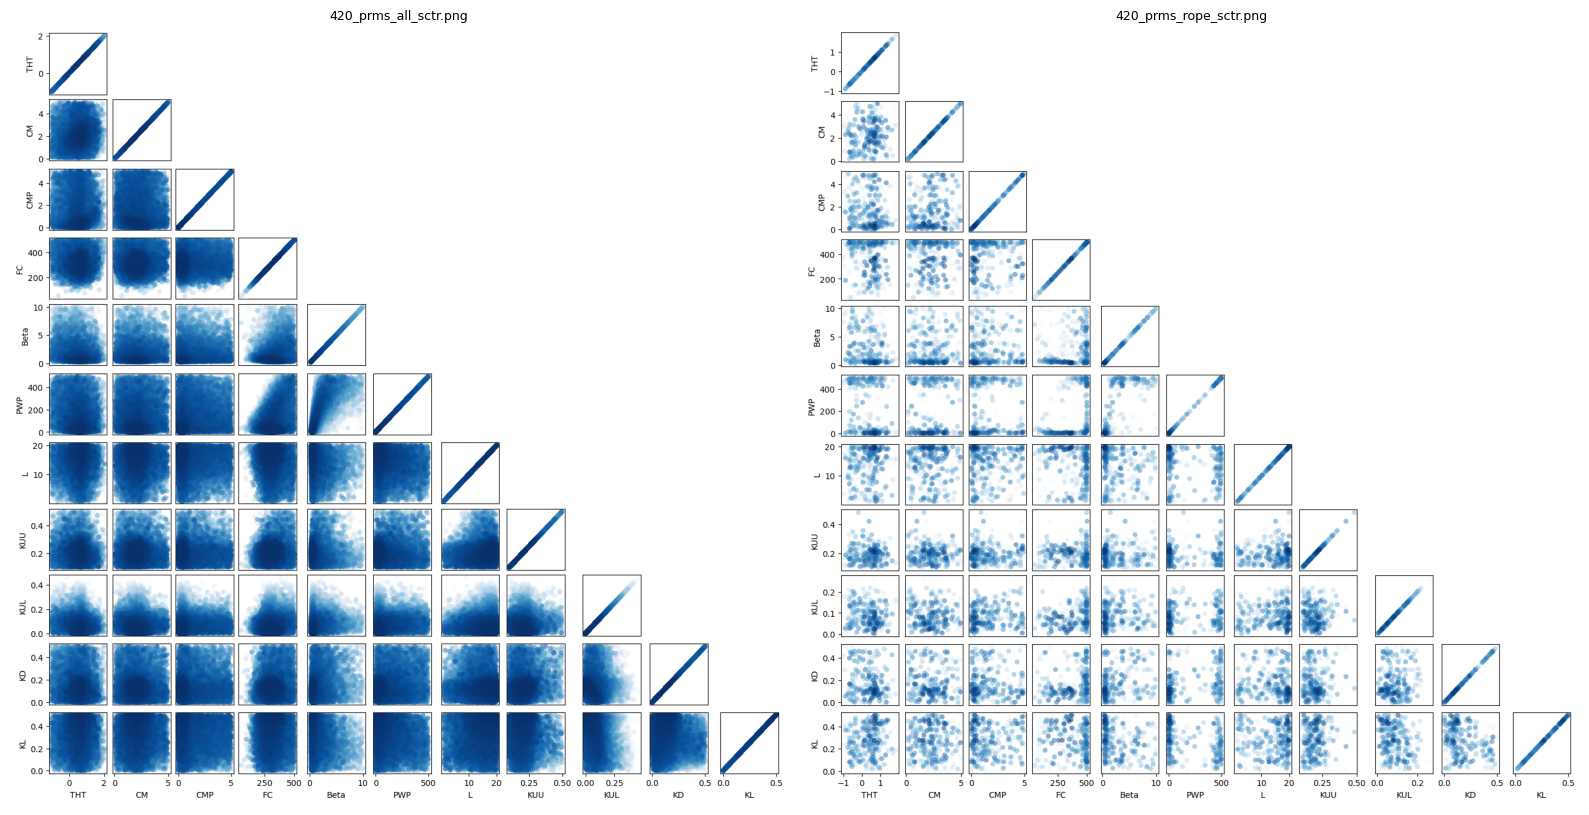

In [6]:
show_grid(
    CAL_71,
    ["420_prms_all_sctr.png", "420_prms_rope_sctr.png"],
    ncols=2,
    figsize=(16, 16),
)

### Interpretation

The **thresholded scatter matrix** still shows a broad region of accepted parameter cloud.  
So even after thresholding, many parameter combinations remain acceptable. That is the equifinality problem.

The figure on the left is after ROPE, and it shows that the **ROPE scatter matrix** is much sparser.  
The dense interior cloud is reduced, and what remains is a smaller set of representative points.



## A5. Selected parameter–objective plots for 1971–1980

The following plots are included because they show the most visible parameter patterns in the ROPE-retained subset.



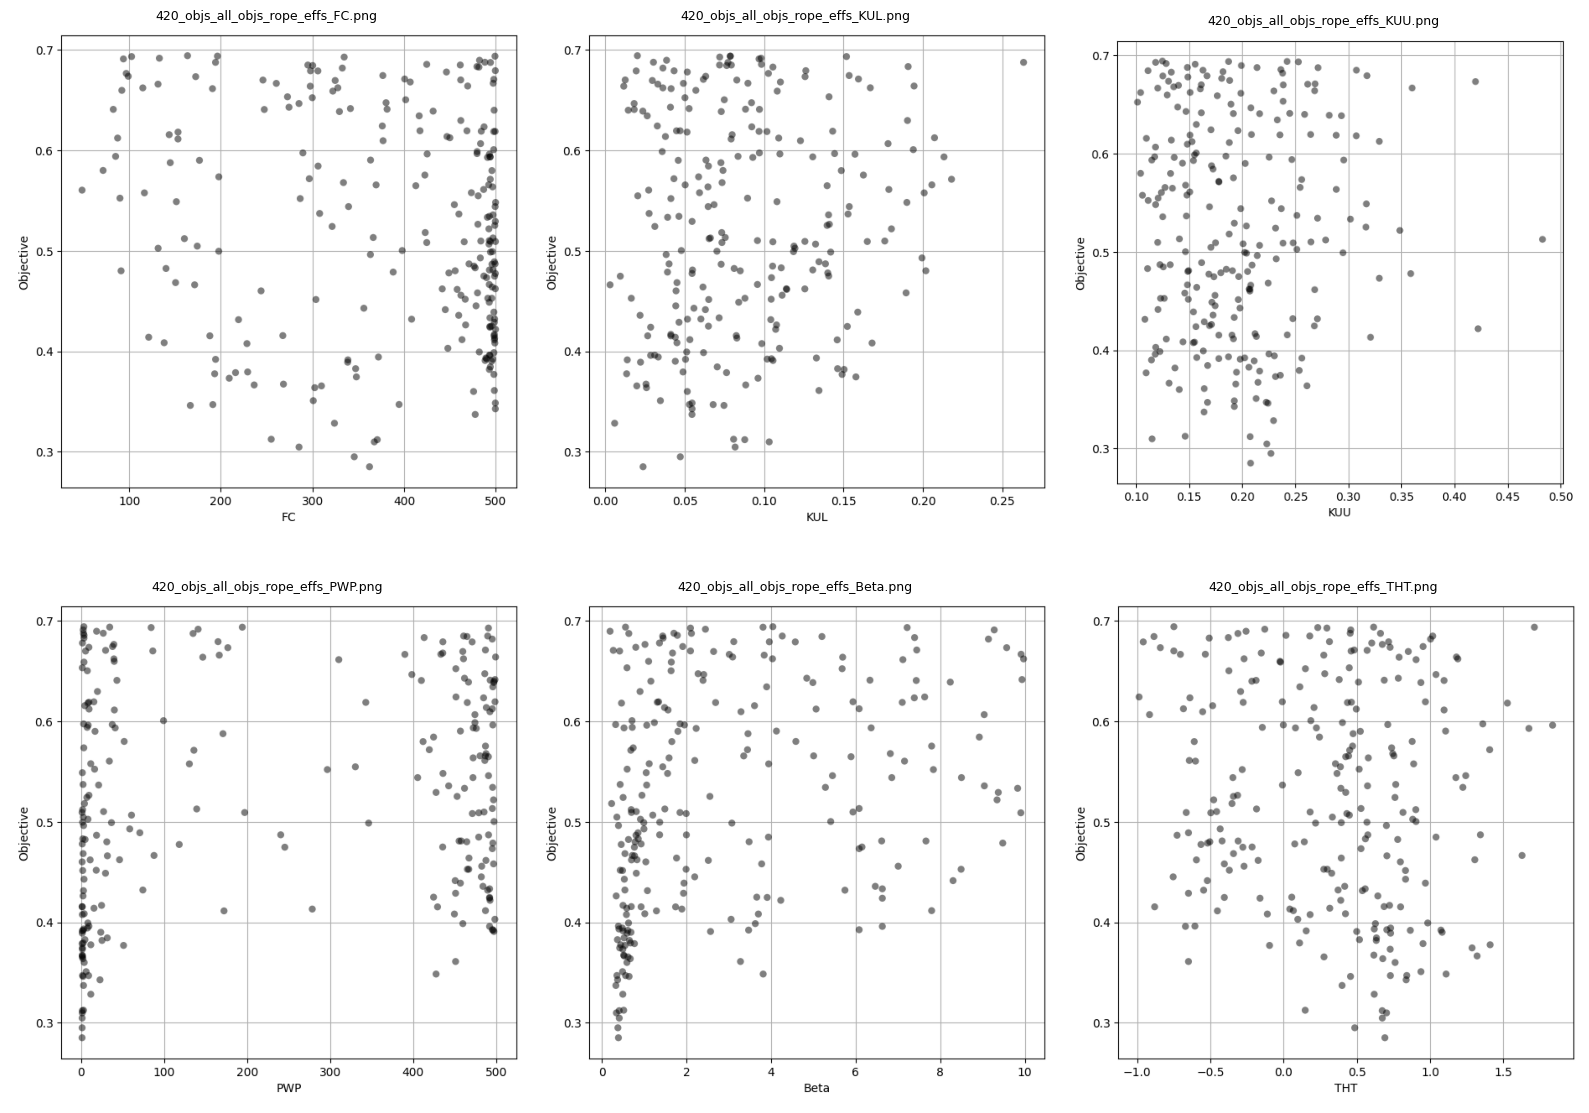

In [7]:
show_grid(
    CAL_71,
    [
        "420_objs_all_objs_rope_effs_FC.png",
        "420_objs_all_objs_rope_effs_KUL.png",
        "420_objs_all_objs_rope_effs_KUU.png",
        "420_objs_all_objs_rope_effs_PWP.png",
        "420_objs_all_objs_rope_effs_Beta.png",
        "420_objs_all_objs_rope_effs_THT.png",
    ],
    ncols=3,
    figsize=(16, 12),
)

### Interpretation

These plots show how the retained objective values are distributed across selected parameters.

Several patterns are visible:

- **FC** is concentrated near the upper boundary, which suggests a clear boundary effect.  
- **KUL** and **KUU** are concentrated toward lower values, indicating stronger constraint.  
- **PWP** shows accumulation near the lower and upper limits, which also points to boundary-type behaviour.  
- **Beta** remains somewhat broad, although better solutions are more common at lower values.  
- **THT** remains broadly distributed and therefore appears weakly constrained.

These figures suggest that not all parameters are equally identifiable within the accepted solution set.


## A6. Validation of the 1971–1980 subset on 1981–1990

The final step for this calibration decade is to examine how the retained subset behaves when transferred to the other decade.


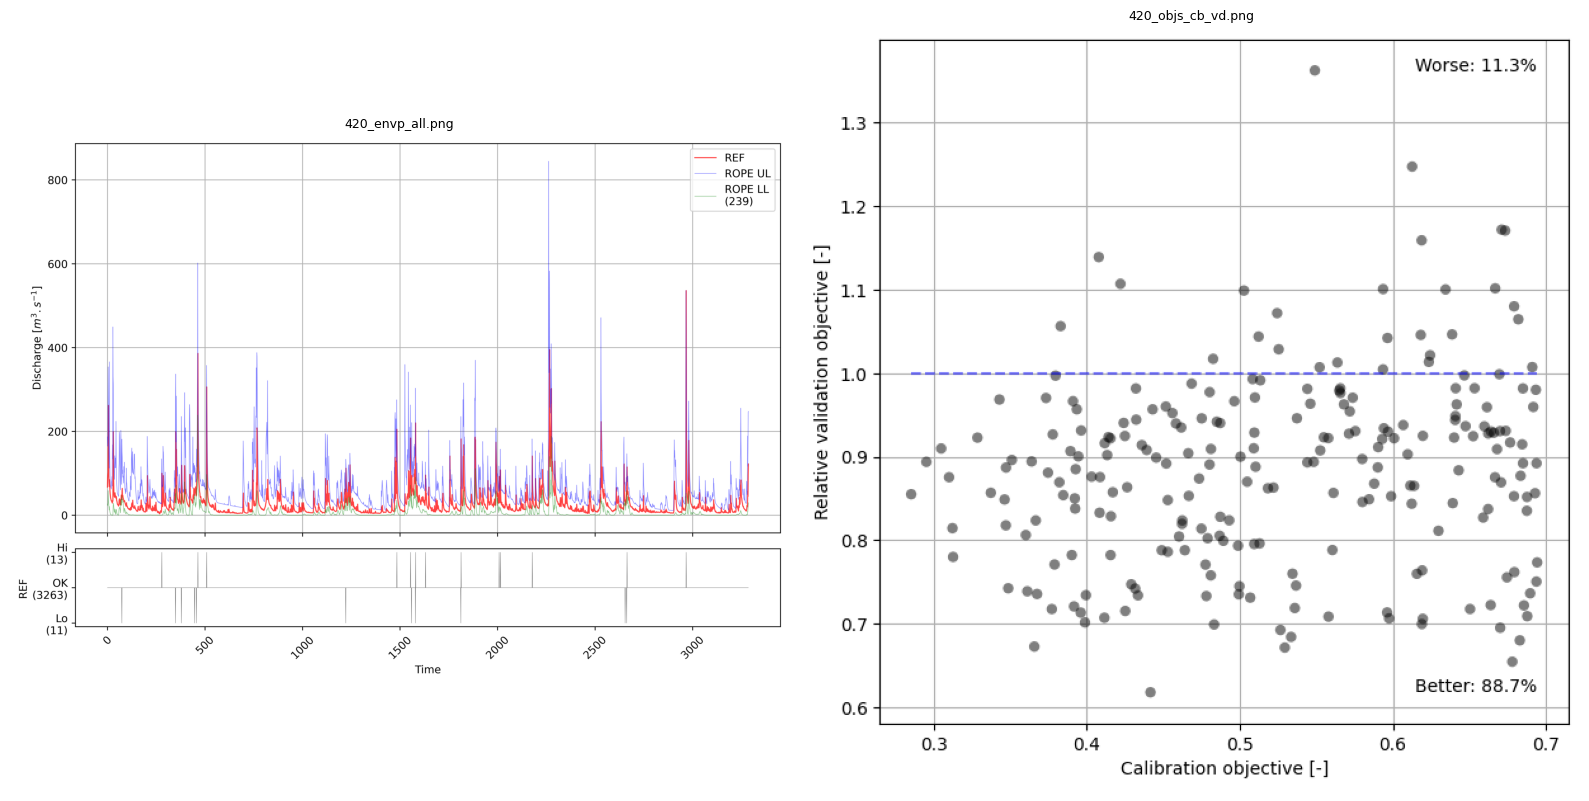

In [8]:
show_grid(
    VAL_71_TO_81,
    ["420_envp_all.png", "420_objs_cb_vd.png"],
    ncols=2,
    figsize=(16, 10),
)

### Interpretation

The **left figure** shows the validation envelope.  
Although the subset was selected from the **1971–1980** calibration, it still covers the observed discharge well on **1981–1990**:

- **Lo = 11**
- **OK = 3263**
- **Hi = 13**

This corresponds to an outside fraction of about **0.73%**.

The **right figure** compares calibration objective values with relative validation objective values.  
Points below the dashed line indicate improved performance in validation, and points above it indicate deterioration.

For this case:

- **Better = 88.7%**
- **Worse = 11.3%**

So this subset transfers relatively well to the opposite decade, both in terms of envelope coverage and objective behaviour.




# Part B. Calibration decade 1981–1990

## B1. Threshold envelope for 1981–1990
The same sequence of figures is now repeated for the second calibration decade.


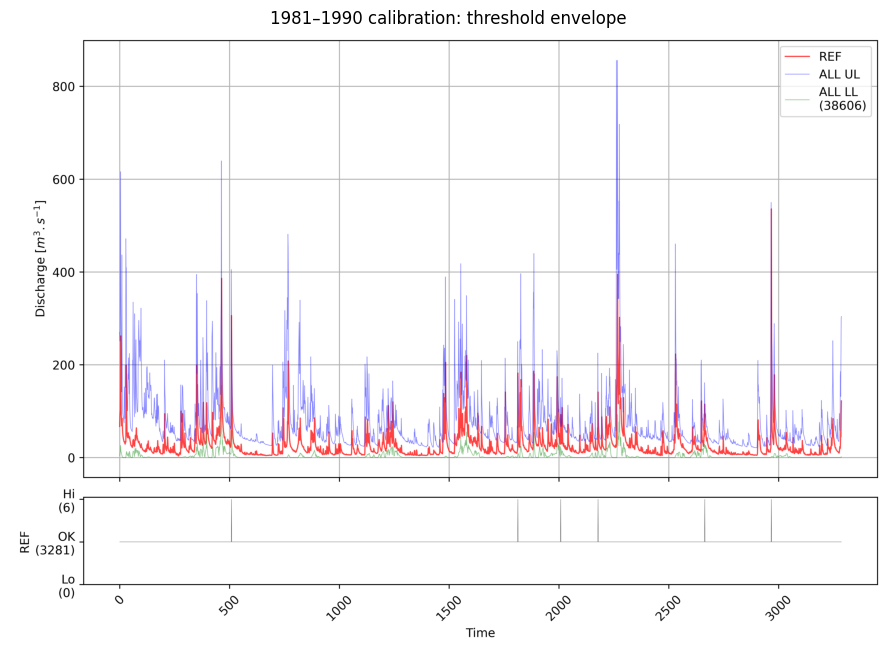

In [9]:
show_image(
    CAL_81,
    "420_envp_all.png",
    figsize=(14, 8),
    title="1981–1990 calibration: threshold envelope"
)

### Interpretation

This figure again shows the observed discharge together with the lower and upper limits of the thresholded ensemble.

For the **1981–1990** calibration period, the counts are:

- **Lo = 0**
- **OK = 3281**
- **Hi = 6**

The outside fraction is therefore about **0.18%**.  
As in the first decade, the thresholded ensemble captures the hydrograph very well, but it remains much larger than needed for a compact uncertainty description.


## B2. ROPE envelope for 1981–1990

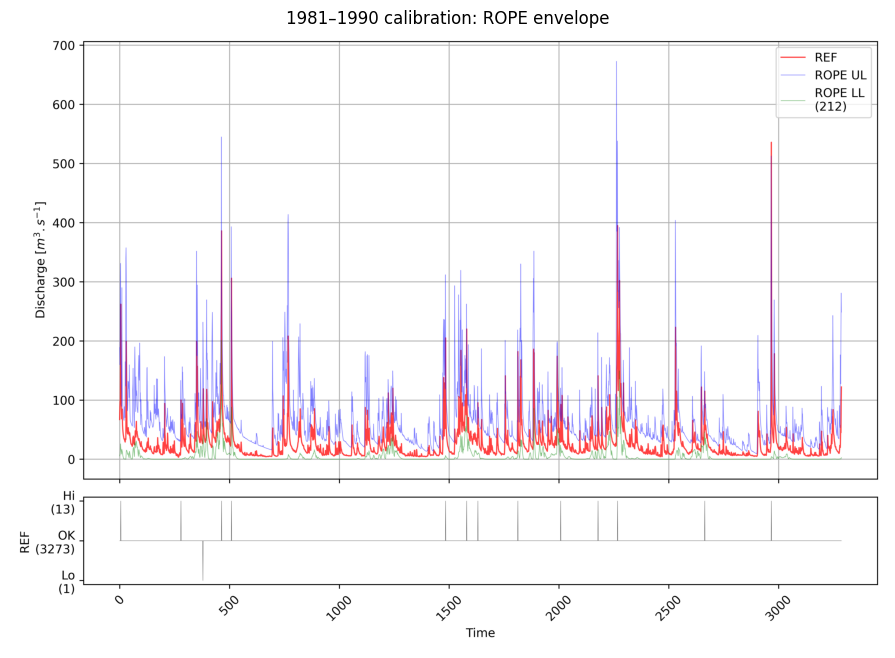

In [10]:
show_image(
    CAL_81,
    "420_envp_rope.png",
    figsize=(14, 8),
    title="1981–1990 calibration: ROPE envelope"
)

### Interpretation

After ROPE, the number of retained parameter vectors is reduced from **38,606** to **212**.

The corresponding envelope counts are:

- **Lo = 1**
- **OK = 3273**
- **Hi = 13**

The outside fraction rises to about **0.43%**, but again remains below 1%.  
So the general outcome is the same as before: ROPE greatly reduces the size of the accepted cloud while still maintaining a satisfactory envelope.


## B3. Objective distribution: thresholded set versus ROPE subset

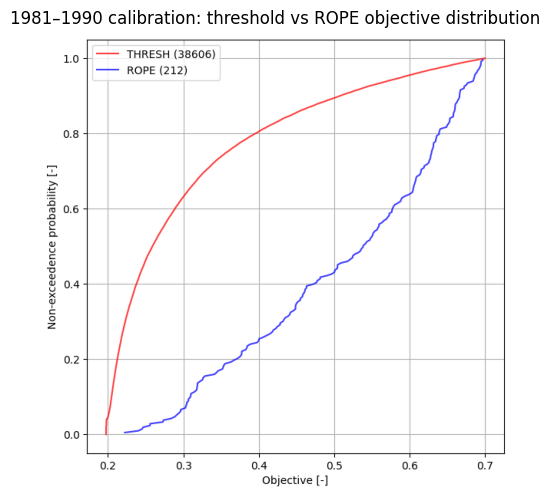

In [11]:
show_image(
    CAL_81,
    "420_objs_all_rope_dist.png",
    figsize=(8, 6),
    title="1981–1990 calibration: threshold vs ROPE objective distribution"
)

### Interpretation

The shape of this comparison is similar to that of the first decade. The ROPE subset is again shifted somewhat toward higher objective values, which shows that the reduced subset is not simply the lowest-objective tail of the thresholded ensemble.

This supports the same interpretation as before: ROPE is selecting a compact and useful subset, not merely the numerically strongest points.


## B4. Parameter cloud before and after ROPE

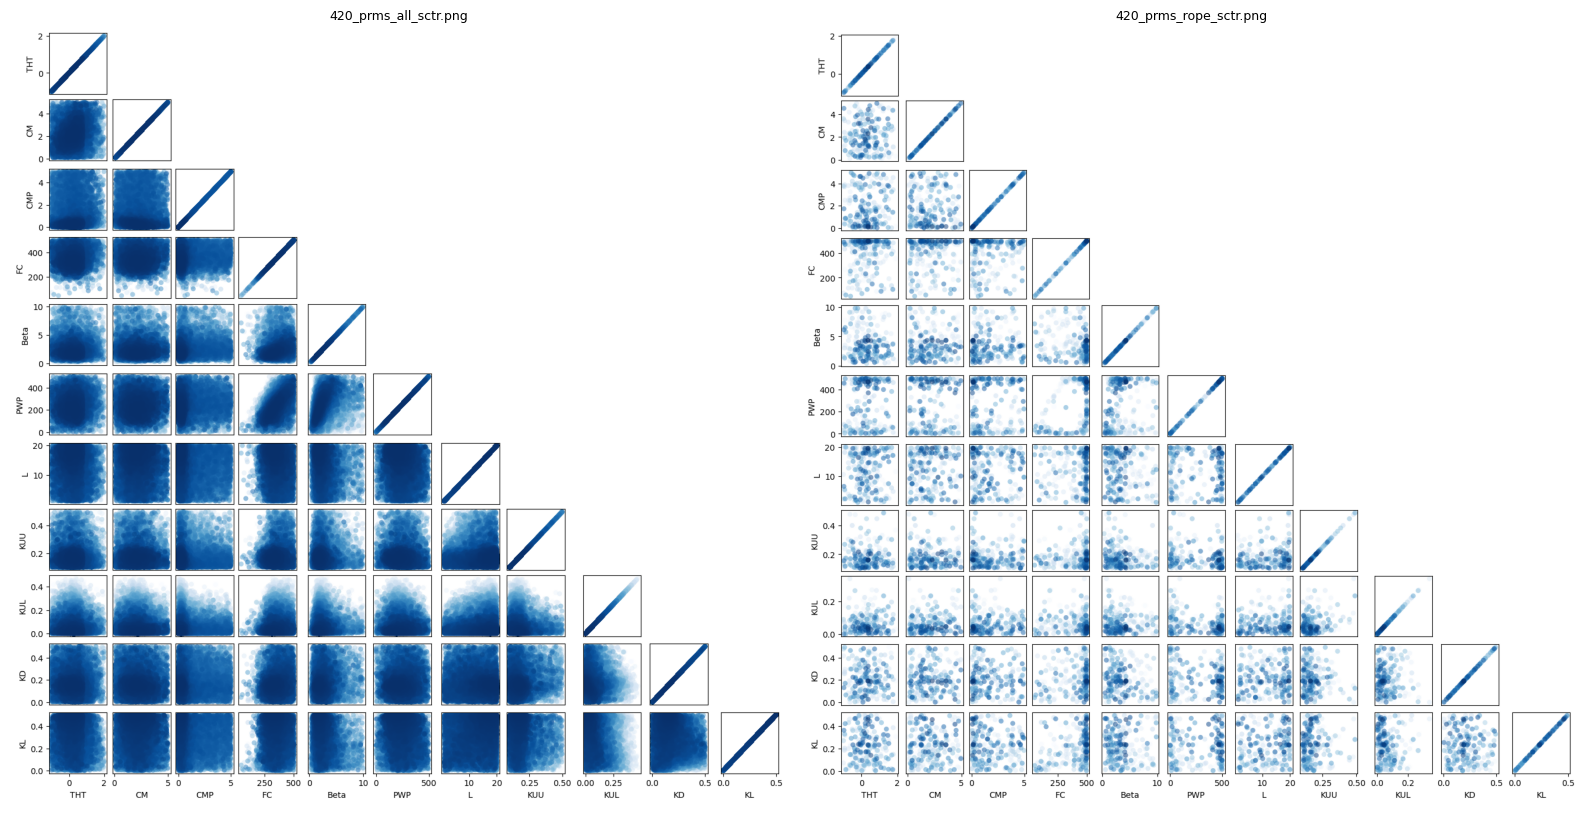

In [12]:
show_grid(
    CAL_81,
    ["420_prms_all_sctr.png", "420_prms_rope_sctr.png"],
    ncols=2,
    figsize=(16, 16),
)

### Interpretation

The thresholded cloud remains broad, which again indicates that many parameter combinations are still acceptable after thresholding.

The ROPE-retained cloud is much smaller and more selective.  
This confirms that ROPE does not erase the structure of the accepted region, but trims it down to a set that is easier to interpret and still informative for uncertainty analysis.


## B5. Selected parameter–objective plots for 1981–1990

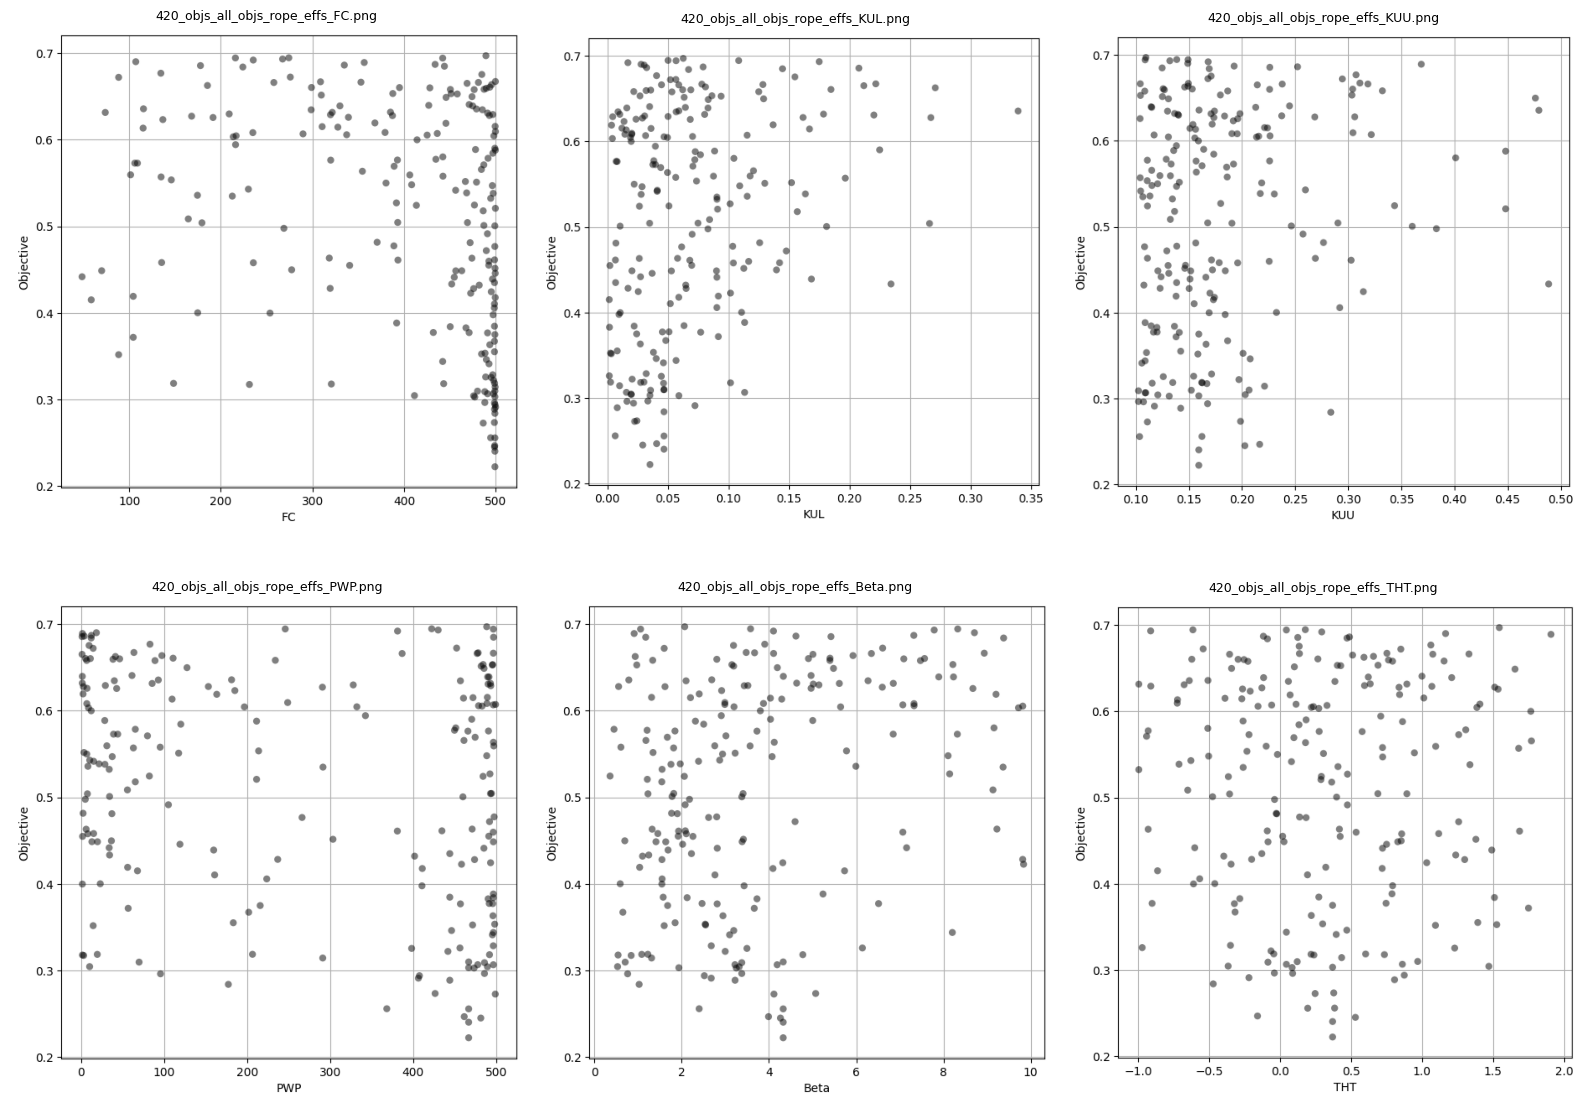

In [13]:
show_grid(
    CAL_81,
    [
        "420_objs_all_objs_rope_effs_FC.png",
        "420_objs_all_objs_rope_effs_KUL.png",
        "420_objs_all_objs_rope_effs_KUU.png",
        "420_objs_all_objs_rope_effs_PWP.png",
        "420_objs_all_objs_rope_effs_Beta.png",
        "420_objs_all_objs_rope_effs_THT.png",
    ],
    ncols=3,
    figsize=(16, 12),
)

### Interpretation

The same broad parameter tendencies appear here as well:

- **FC** still accumulates near the upper limit.  
- **KUL** and **KUU** remain concentrated toward lower values.  
- **PWP** again shows boundary-type accumulation.  
- **Beta** is broad but favours lower values among the better solutions.  
- **THT** remains spread out and therefore weakly constrained.

The exact details differ from decade to decade, but the main parameter story is broadly consistent.


## B6. Validation of the 1981–1990 subset on 1971–1980

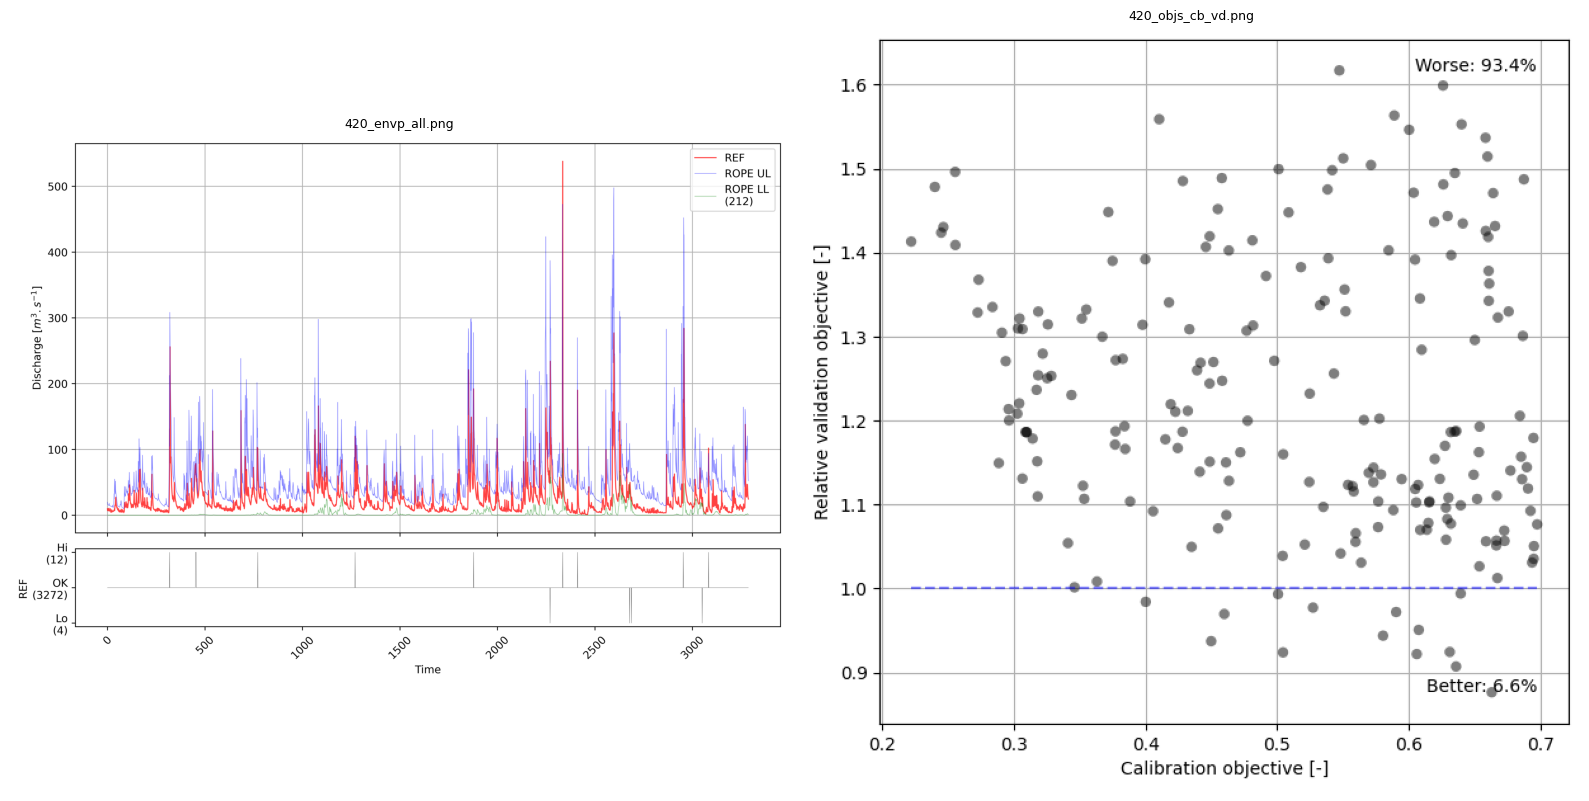

In [14]:
show_grid(
    VAL_81_TO_71,
    ["420_envp_all.png", "420_objs_cb_vd.png"],
    ncols=2,
    figsize=(16, 10),
)

### Interpretation

The **left figure** shows the validation envelope on the opposite decade.  
Even after transfer, the subset still provides good envelope coverage:

- **Lo = 4**
- **OK = 3272**
- **Hi = 12**

This gives an outside fraction of about **0.49%**.

The **right figure** again compares calibration and validation objective values.  
Here the result is different from the first transfer direction:

- **Better = 6.6%**
- **Worse = 93.4%**

So the envelope remains acceptable, but the objective behaviour deteriorates much more often in this direction. This indicates that the two decades are not equally symmetric in cross-decade transferability.


# Conclusion



For both calibration periods, the thresholded ensemble provides very strong envelope coverage.  
In both cases, ROPE reduces the accepted cloud sharply while preserving a good level of hydrograph coverage. 




The largest difference appears in validation.

- The subset derived from **1971–1980** transfers relatively well to **1981–1990**.  
- The subset derived from **1981–1990** still gives an acceptable validation envelope on **1971–1980**, but its objective values become worse much more often.

This shows that the reduced subsets are not equally transferable in both directions.
